In [1]:
# Load filtered data summary
from pathlib import Path
import pyarrow as pa
from datasets import Dataset

FILTERED_ROOT = Path("./output/construction_site_test/filtered")
ORIGINAL_ARROW = Path("./LouisChen15___construction_site/construction_site-test.arrow")

# List filtered files
filtered_files = sorted(FILTERED_ROOT.glob("filtered_*.arrow"))

print("="*70)
print("Filtered Dataset Summary")
print("="*70)

filtered_datasets = {}
total = 0
for f in filtered_files:
    with pa.memory_map(str(f), 'r') as source:
        reader = pa.ipc.open_stream(source)
        table = reader.read_all()
    ds = Dataset(table)
    size_mb = f.stat().st_size / (1024*1024)
    style_name = f.stem.replace('filtered_', '').split('_ssim')[0]
    filtered_datasets[style_name] = ds
    print(f"  • {style_name}: {len(ds)} samples ({size_mb:.2f} MB)")
    total += len(ds)

print("="*70)
print(f"Total filtered samples: {total}")
print("="*70)

# Load original dataset
print("\n📂 Loading original dataset for comparison...")
with pa.memory_map(str(ORIGINAL_ARROW), 'r') as source:
    reader = pa.ipc.open_stream(source)
    table = reader.read_all()
original_ds = Dataset(table)
print(f"✅ Original dataset: {len(original_ds)} samples")

/users/PGS0407/binben14/.conda/envs/VLM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filtered Dataset Summary
  • style_rain_0: 2211 samples (1072.83 MB)
  • style_rain_1: 1243 samples (481.43 MB)
  • style_rain_2: 1208 samples (464.79 MB)
  • style_snow_0: 2159 samples (1104.32 MB)
  • style_snow_1: 1649 samples (1043.64 MB)
  • style_snow_2: 1796 samples (984.45 MB)
Total filtered samples: 10266

📂 Loading original dataset for comparison...
✅ Original dataset: 3004 samples


In [1]:
# Load filtered data summary
from pathlib import Path
import pyarrow as pa
from datasets import Dataset

FILTERED_ROOT = Path("./output/construction_site_test/night")
ORIGINAL_ARROW = Path("./LouisChen15___construction_site/construction_site-test.arrow")

# List filtered files
filtered_files = sorted(FILTERED_ROOT.glob("batch_*.arrow"))

print("="*70)
print("Filtered Dataset Summary")
print("="*70)

filtered_datasets = {}
total = 0
for f in filtered_files:
    with pa.memory_map(str(f), 'r') as source:
        reader = pa.ipc.open_stream(source)
        table = reader.read_all()
    ds = Dataset(table)
    size_mb = f.stat().st_size / (1024*1024)
    style_name = f.stem.replace('filtered_', '').split('_ssim')[0]
    filtered_datasets[style_name] = ds
    print(f"  • {style_name}: {len(ds)} samples ({size_mb:.2f} MB)")
    total += len(ds)

print("="*70)
print(f"Total filtered samples: {total}")
print("="*70)

# Load original dataset
print("\n📂 Loading original dataset for comparison...")
with pa.memory_map(str(ORIGINAL_ARROW), 'r') as source:
    reader = pa.ipc.open_stream(source)
    table = reader.read_all()
original_ds = Dataset(table)
print(f"✅ Original dataset: {len(original_ds)} samples")

/users/PGS0407/binben14/.conda/envs/VLM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filtered Dataset Summary
  • batch_0000: 100 samples (22.87 MB)
  • batch_0001: 100 samples (22.17 MB)
  • batch_0002: 100 samples (20.70 MB)
  • batch_0003: 100 samples (21.15 MB)
  • batch_0004: 100 samples (20.55 MB)
  • batch_0005: 100 samples (19.91 MB)
  • batch_0006: 100 samples (21.25 MB)
  • batch_0007: 100 samples (22.57 MB)
  • batch_0008: 100 samples (23.45 MB)
  • batch_0009: 100 samples (20.74 MB)
  • batch_0010: 100 samples (21.21 MB)
  • batch_0011: 100 samples (23.69 MB)
  • batch_0012: 100 samples (21.84 MB)
  • batch_0013: 100 samples (21.64 MB)
  • batch_0014: 100 samples (20.73 MB)
  • batch_0016: 100 samples (22.98 MB)
  • batch_0017: 100 samples (21.71 MB)
  • batch_0018: 100 samples (24.71 MB)
  • batch_0019: 100 samples (21.92 MB)
  • batch_0020: 100 samples (20.70 MB)
  • batch_0021: 100 samples (21.53 MB)
  • batch_0022: 100 samples (20.01 MB)
  • batch_0023: 100 samples (22.46 MB)
  • batch_0024: 100 samples (23.23 MB)
  • batch_0025: 100 samples (22.88 MB)


In [4]:
# Build original index for fast lookup - BY INDEX and image_id
# Because ref_id in night batches is the integer index in original dataset
original_by_idx = {idx: original_ds[idx] for idx in range(len(original_ds))}
original_by_image_id = {sample['image_id']: sample for sample in original_ds}

# Label fields to verify (exclude image and ref_id)
label_fields = ['image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 
                'quality_of_info', 'rule_1_violation', 'rule_2_violation', 
                'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 
                'worker_with_white_hard_hat']

print("🔍 Verifying labels match with original data...")
print("="*70)

all_match = True
mismatch_count = 0
total_checked = 0

for style_name, filtered_ds in filtered_datasets.items():
    style_mismatches = 0
    
    for idx in range(len(filtered_ds)):
        filtered_sample = filtered_ds[idx]
        ref_id = filtered_sample.get('ref_id')
        
        # ref_id is integer index for night batches
        if ref_id is not None and isinstance(ref_id, int):
            if ref_id >= len(original_ds):
                print(f"⚠️  ref_id {ref_id} out of range")
                continue
            original_sample = original_by_idx[ref_id]
        else:
            # Fallback to image_id for other datasets
            image_id = filtered_sample.get('image_id')
            if image_id not in original_by_image_id:
                print(f"⚠️  image_id {image_id} not found in original dataset")
                continue
            original_sample = original_by_image_id[image_id]
        
        # Check each label field
        for field in label_fields:
            if field in filtered_sample and field in original_sample:
                if filtered_sample[field] != original_sample[field]:
                    style_mismatches += 1
                    all_match = False
                    if mismatch_count < 5:  # Show first 5 mismatches
                        print(f"❌ Mismatch in {style_name}, ref_id={ref_id}, field={field}")
                        print(f"   Filtered: {filtered_sample[field]}")
                        print(f"   Original: {original_sample[field]}")
                    mismatch_count += 1
        
        total_checked += 1
    
    status = "✅" if style_mismatches == 0 else "❌"
    print(f"{status} {style_name}: Checked {len(filtered_ds)} samples, {style_mismatches} mismatches")

print("="*70)
if all_match:
    print(f"✅ All labels verified! {total_checked} samples checked, 0 mismatches")
else:
    print(f"❌ Found {mismatch_count} label mismatches in {total_checked} samples")
print("="*70)

🔍 Verifying labels match with original data...
✅ batch_0000: Checked 100 samples, 0 mismatches
✅ batch_0001: Checked 100 samples, 0 mismatches
✅ batch_0002: Checked 100 samples, 0 mismatches
✅ batch_0003: Checked 100 samples, 0 mismatches
✅ batch_0004: Checked 100 samples, 0 mismatches
✅ batch_0005: Checked 100 samples, 0 mismatches
✅ batch_0006: Checked 100 samples, 0 mismatches
✅ batch_0007: Checked 100 samples, 0 mismatches
✅ batch_0008: Checked 100 samples, 0 mismatches
✅ batch_0009: Checked 100 samples, 0 mismatches
✅ batch_0010: Checked 100 samples, 0 mismatches
✅ batch_0011: Checked 100 samples, 0 mismatches
✅ batch_0012: Checked 100 samples, 0 mismatches
✅ batch_0013: Checked 100 samples, 0 mismatches
✅ batch_0014: Checked 100 samples, 0 mismatches
✅ batch_0016: Checked 100 samples, 0 mismatches
✅ batch_0017: Checked 100 samples, 0 mismatches
✅ batch_0018: Checked 100 samples, 0 mismatches
✅ batch_0019: Checked 100 samples, 0 mismatches
✅ batch_0020: Checked 100 samples, 0 mism

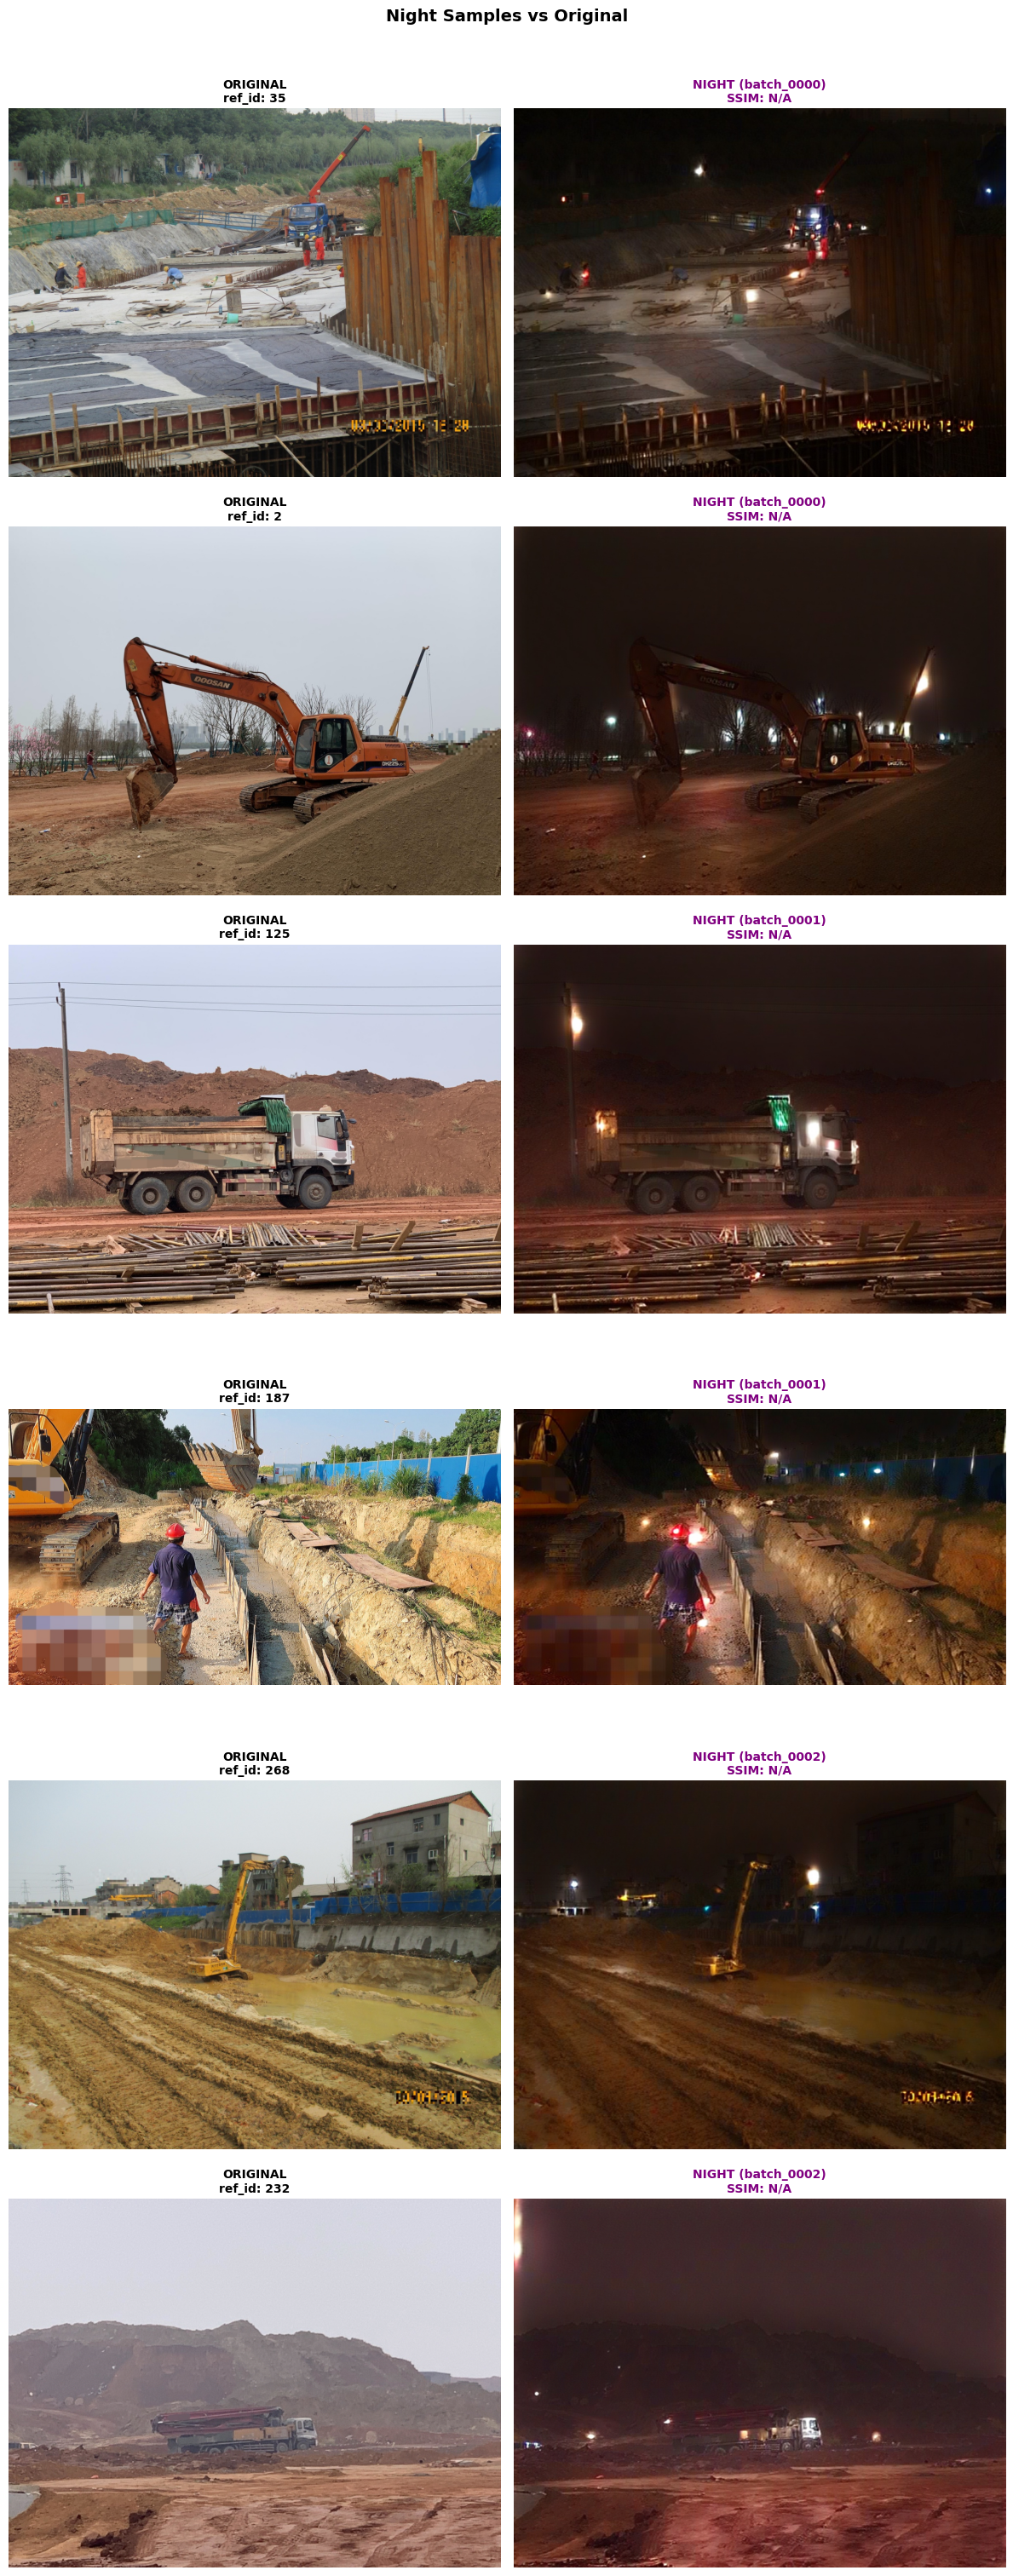


✅ Showing 6 random night samples


In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import io
import random

def to_pil_image(img_data):
    """Convert image data to PIL Image"""
    if isinstance(img_data, Image.Image):
        return img_data
    elif isinstance(img_data, bytes):
        return Image.open(io.BytesIO(img_data))
    elif isinstance(img_data, dict) and 'bytes' in img_data:
        return Image.open(io.BytesIO(img_data['bytes']))
    else:
        return img_data

# Pick random samples from each filtered dataset
NUM_SAMPLES_PER_STYLE = 2
samples_to_show = []

for style_name, filtered_ds in filtered_datasets.items():
    indices = random.sample(range(len(filtered_ds)), min(NUM_SAMPLES_PER_STYLE, len(filtered_ds)))
    for idx in indices:
        filtered_sample = filtered_ds[idx]
        ref_id = filtered_sample.get('ref_id')
        
        # Get original sample - ref_id is integer index for night batches
        if ref_id is not None and isinstance(ref_id, int):
            if ref_id < len(original_ds):
                original_sample = original_by_idx[ref_id]
                samples_to_show.append({
                    'style': style_name,
                    'filtered': filtered_sample,
                    'original': original_sample,
                    'ref_id': ref_id,
                    'ssim': filtered_sample.get('ssim_score', 'N/A')
                })
        else:
            # Fallback to image_id
            image_id = filtered_sample.get('image_id')
            if image_id in original_by_image_id:
                samples_to_show.append({
                    'style': style_name,
                    'filtered': filtered_sample,
                    'original': original_by_image_id[image_id],
                    'ref_id': ref_id or image_id,
                    'ssim': filtered_sample.get('ssim_score', 'N/A')
                })

# Visualize
num_samples = min(6, len(samples_to_show))
fig, axes = plt.subplots(num_samples, 2, figsize=(12, 5*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for row, sample_info in enumerate(samples_to_show[:num_samples]):
    orig_img = to_pil_image(sample_info['original']['image'])
    filt_img = to_pil_image(sample_info['filtered']['image'])
    
    # Original (left)
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"ORIGINAL\nref_id: {sample_info['ref_id']}", fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')
    
    # Filtered (right)
    ssim_val = sample_info['ssim']
    ssim_str = f"{ssim_val:.4f}" if isinstance(ssim_val, float) else ssim_val
    axes[row, 1].imshow(filt_img)
    axes[row, 1].set_title(f"NIGHT ({sample_info['style']})\nSSIM: {ssim_str}", 
                           fontsize=10, fontweight='bold', color='purple')
    axes[row, 1].axis('off')

plt.suptitle('Night Samples vs Original', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n✅ Showing {num_samples} random night samples")

In [6]:
# Detailed label comparison for a sample
sample_info = samples_to_show[0]  # Use first sample
filtered_sample = sample_info['filtered']
original_sample = sample_info['original']

print("="*70)
print(f"Label Comparison for ref_id: {sample_info['ref_id']} ({sample_info['style']})")
print("="*70)
print(f"{'Field':<30} {'Original':<25} {'Filtered':<25} {'Match'}")
print("-"*70)

for field in label_fields:
    orig_val = original_sample.get(field, 'N/A')
    filt_val = filtered_sample.get(field, 'N/A')
    match = "✅" if orig_val == filt_val else "❌"
    
    # Truncate long strings
    orig_str = str(orig_val)[:22] + "..." if len(str(orig_val)) > 25 else str(orig_val)
    filt_str = str(filt_val)[:22] + "..." if len(str(filt_val)) > 25 else str(filt_val)
    
    print(f"{field:<30} {orig_str:<25} {filt_str:<25} {match}")

# Show additional columns in filtered (like ssim_score)
print("\n📊 Additional columns in filtered data:")
for key in filtered_sample.keys():
    if key not in label_fields and key not in ['image', 'ref_id']:
        val = filtered_sample[key]
        if isinstance(val, float):
            print(f"  • {key}: {val:.4f}")
        else:
            print(f"  • {key}: {val}")

print("="*70)

Label Comparison for ref_id: 35 (batch_0000)
Field                          Original                  Filtered                  Match
----------------------------------------------------------------------
image_id                       0000057                   0000057                   ✅
image_caption                  Seven workers are in a... Seven workers are in a... ✅
illumination                   normal lighting           normal lighting           ✅
camera_distance                long distance             long distance             ✅
view                           elevation view            elevation view            ✅
quality_of_info                rich info                 rich info                 ✅
rule_1_violation               None                      None                      ✅
rule_2_violation               None                      None                      ✅
rule_3_violation               None                      None                      ✅
rule_4_violation              

In [7]:
# Show only SNOW samples
snow_samples = []

for style_name, filtered_ds in filtered_datasets.items():
    if 'snow' in style_name.lower():
        indices = random.sample(range(len(filtered_ds)), min(3, len(filtered_ds)))
        for idx in indices:
            filtered_sample = filtered_ds[idx]
            ref_id = filtered_sample.get('ref_id', filtered_sample.get('image_id'))
            if ref_id in original_index:
                snow_samples.append({
                    'style': style_name,
                    'filtered': filtered_sample,
                    'original': original_index[ref_id],
                    'ref_id': ref_id,
                    'ssim': filtered_sample.get('ssim_score', 'N/A')
                })

# Visualize snow samples
num_samples = min(6, len(snow_samples))
fig, axes = plt.subplots(num_samples, 2, figsize=(12, 5*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for row, sample_info in enumerate(snow_samples[:num_samples]):
    orig_img = to_pil_image(sample_info['original']['image'])
    filt_img = to_pil_image(sample_info['filtered']['image'])
    
    # Original (left)
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"ORIGINAL\nref_id: {sample_info['ref_id']}", fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')
    
    # Filtered (right)
    ssim_val = sample_info['ssim']
    ssim_str = f"{ssim_val:.4f}" if isinstance(ssim_val, float) else ssim_val
    axes[row, 1].imshow(filt_img)
    axes[row, 1].set_title(f"SNOW ({sample_info['style']})\nSSIM: {ssim_str}", 
                           fontsize=10, fontweight='bold', color='blue')
    axes[row, 1].axis('off')

plt.suptitle('Snow Augmented Samples vs Original', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n✅ Showing {num_samples} random SNOW samples")

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1200x0 with 0 Axes>

In [ ]:
# ========== VISUALIZE DATA FROM last_data/construction_site_test/day/filtered ==========
from pathlib import Path
import pyarrow as pa
from datasets import Dataset
import matplotlib.pyplot as plt
from PIL import Image
import io
import random

LAST_DATA_FILTERED = Path("./last_data/construction_site_test/day/filtered")

# List filtered files
last_filtered_files = sorted(LAST_DATA_FILTERED.glob("filtered_*.arrow"))

print("="*70)
print("Last Data - Day Filtered Dataset Summary")
print("="*70)

last_filtered_datasets = {}
total = 0
for f in last_filtered_files:
    with pa.memory_map(str(f), 'r') as source:
        reader = pa.ipc.open_stream(source)
        table = reader.read_all()
    ds = Dataset(table)
    size_mb = f.stat().st_size / (1024*1024)
    style_name = f.stem.replace('filtered_', '').split('_ssim')[0]
    last_filtered_datasets[style_name] = ds
    print(f"  • {style_name}: {len(ds)} samples ({size_mb:.2f} MB)")
    total += len(ds)

print("="*70)
print(f"Total filtered samples: {total}")
print(f"Styles: {list(last_filtered_datasets.keys())}")
print("="*70)

Last Data - Day Filtered Dataset Summary


In [ ]:
# Visualize random samples from last_data filtered datasets
def to_pil_image(img_data):
    """Convert image data to PIL Image"""
    if isinstance(img_data, Image.Image):
        return img_data
    elif isinstance(img_data, bytes):
        return Image.open(io.BytesIO(img_data))
    elif isinstance(img_data, dict) and 'bytes' in img_data:
        return Image.open(io.BytesIO(img_data['bytes']))
    else:
        return img_data

# Collect samples from each style
NUM_SAMPLES_PER_STYLE = 2
last_samples = []

for style_name, ds in last_filtered_datasets.items():
    indices = random.sample(range(len(ds)), min(NUM_SAMPLES_PER_STYLE, len(ds)))
    for idx in indices:
        sample = ds[idx]
        last_samples.append({
            'style': style_name,
            'sample': sample,
            'ssim': sample.get('ssim_score', 'N/A')
        })

# Shuffle samples
random.shuffle(last_samples)

# Visualize
num_samples = min(12, len(last_samples))
cols = 3
rows = (num_samples + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for i, sample_info in enumerate(last_samples[:num_samples]):
    img = to_pil_image(sample_info['sample']['image'])
    ssim_val = sample_info['ssim']
    ssim_str = f"{ssim_val:.4f}" if isinstance(ssim_val, float) else ssim_val
    
    # Determine color based on weather type
    if 'rain' in sample_info['style']:
        color = 'blue'
        emoji = '🌧️'
    else:
        color = 'cyan'
        emoji = '❄️'
    
    axes[i].imshow(img)
    axes[i].set_title(f"{emoji} {sample_info['style']}\nSSIM: {ssim_str}", fontsize=10, color=color)
    axes[i].axis('off')

# Hide unused axes
for i in range(num_samples, len(axes)):
    axes[i].axis('off')

plt.suptitle('Day Filtered Samples (last_data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ Showing {num_samples} random samples from last_data/construction_site_test/day/filtered")

In [ ]:
# Side-by-side comparison: Rain vs Snow styles
rain_samples = [s for s in last_samples if 'rain' in s['style']]
snow_samples = [s for s in last_samples if 'snow' in s['style']]

num_pairs = min(3, len(rain_samples), len(snow_samples))

fig, axes = plt.subplots(num_pairs, 2, figsize=(12, 5*num_pairs))
if num_pairs == 1:
    axes = axes.reshape(1, -1)

for row in range(num_pairs):
    # Rain (left)
    rain_img = to_pil_image(rain_samples[row]['sample']['image'])
    rain_ssim = rain_samples[row]['ssim']
    rain_ssim_str = f"{rain_ssim:.4f}" if isinstance(rain_ssim, float) else rain_ssim
    axes[row, 0].imshow(rain_img)
    axes[row, 0].set_title(f"🌧️ RAIN ({rain_samples[row]['style']})\nSSIM: {rain_ssim_str}", 
                           fontsize=11, color='blue', fontweight='bold')
    axes[row, 0].axis('off')
    
    # Snow (right)
    snow_img = to_pil_image(snow_samples[row]['sample']['image'])
    snow_ssim = snow_samples[row]['ssim']
    snow_ssim_str = f"{snow_ssim:.4f}" if isinstance(snow_ssim, float) else snow_ssim
    axes[row, 1].imshow(snow_img)
    axes[row, 1].set_title(f"❄️ SNOW ({snow_samples[row]['style']})\nSSIM: {snow_ssim_str}", 
                           fontsize=11, color='cyan', fontweight='bold')
    axes[row, 1].axis('off')

plt.suptitle('Rain vs Snow Augmented Samples (Day)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n✅ Showing {num_pairs} pairs of rain vs snow samples")

In [ ]:
# SSIM distribution statistics for last_data filtered
import numpy as np

print("="*70)
print("SSIM Statistics for last_data/construction_site_test/day/filtered")
print("="*70)
print(f"{'Style':<20} {'Count':<8} {'Min':<8} {'Max':<8} {'Mean':<8} {'Std':<8}")
print("-"*70)

for style_name, ds in last_filtered_datasets.items():
    ssim_scores = [s.get('ssim_score', 0) for s in ds if s.get('ssim_score') is not None]
    if ssim_scores:
        ssim_arr = np.array(ssim_scores)
        print(f"{style_name:<20} {len(ssim_arr):<8} {ssim_arr.min():.4f}   {ssim_arr.max():.4f}   {ssim_arr.mean():.4f}   {ssim_arr.std():.4f}")
    else:
        print(f"{style_name:<20} {len(ds):<8} N/A")

print("="*70)

# Histogram of SSIM scores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rain histogram
rain_ssim = []
for style_name, ds in last_filtered_datasets.items():
    if 'rain' in style_name:
        rain_ssim.extend([s.get('ssim_score', 0) for s in ds if s.get('ssim_score') is not None])

if rain_ssim:
    axes[0].hist(rain_ssim, bins=30, color='blue', alpha=0.7, edgecolor='black')
    axes[0].set_title(f'🌧️ Rain SSIM Distribution (n={len(rain_ssim)})', fontweight='bold')
    axes[0].set_xlabel('SSIM Score')
    axes[0].set_ylabel('Count')
    axes[0].axvline(np.mean(rain_ssim), color='red', linestyle='--', label=f'Mean: {np.mean(rain_ssim):.4f}')
    axes[0].legend()

# Snow histogram
snow_ssim = []
for style_name, ds in last_filtered_datasets.items():
    if 'snow' in style_name:
        snow_ssim.extend([s.get('ssim_score', 0) for s in ds if s.get('ssim_score') is not None])

if snow_ssim:
    axes[1].hist(snow_ssim, bins=30, color='cyan', alpha=0.7, edgecolor='black')
    axes[1].set_title(f'❄️ Snow SSIM Distribution (n={len(snow_ssim)})', fontweight='bold')
    axes[1].set_xlabel('SSIM Score')
    axes[1].set_ylabel('Count')
    axes[1].axvline(np.mean(snow_ssim), color='red', linestyle='--', label=f'Mean: {np.mean(snow_ssim):.4f}')
    axes[1].legend()

plt.tight_layout()
plt.show()

# Visualize Style Transfer Output (Snow)

In [ ]:
import pyarrow as pa
from pathlib import Path
import io
from PIL import Image
import matplotlib.pyplot as plt
import json

# Load the arrow file
arrow_path = Path("/users/PGS0407/binben14/VietHuy/construction-site/output/construction_site_test/style_snow_0/batch_0-100.arrow")

print(f"Loading: {arrow_path}")
print(f"File exists: {arrow_path.exists()}")

with open(arrow_path, 'rb') as f:
    reader = pa.ipc.open_stream(f)
    table = reader.read_all()

print(f"\n✅ Loaded successfully!")
print(f"Total samples: {len(table)}")
print(f"Columns: {table.column_names}")

In [ ]:
# Display first 3 samples
num_samples = min(3, len(table))

fig, axes = plt.subplots(num_samples, 2, figsize=(14, 5*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_samples):
    # Get image
    image_data = table['image'][idx].as_py()
    if isinstance(image_data, dict) and 'bytes' in image_data:
        img = Image.open(io.BytesIO(image_data['bytes'])).convert('RGB')
    else:
        img = Image.open(io.BytesIO(image_data)).convert('RGB')
    
    # Display image
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"Sample {idx} - Image")
    axes[idx, 0].axis('off')
    
    # Display metadata
    meta_text = f"Image ID: {table['image_id'][idx].as_py()}\n"
    meta_text += f"Size: {img.size}\n"
    
    # Add other columns info
    for col in table.column_names:
        if col != 'image':
            val = table[col][idx].as_py()
            if isinstance(val, (dict, list)):
                meta_text += f"{col}: {str(val)[:50]}...\n"
            else:
                meta_text += f"{col}: {val}\n"
    
    axes[idx, 1].text(0.05, 0.95, meta_text, transform=axes[idx, 1].transAxes,
                     fontsize=10, verticalalignment='top', fontfamily='monospace',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[idx, 1].axis('off')
    axes[idx, 1].set_title(f"Sample {idx} - Metadata")

plt.tight_layout()
plt.show()

print(f"\n✅ Displayed first {num_samples} samples")

In [ ]:
# Summary statistics
print("=" * 70)
print("ARROW FILE SUMMARY")
print("=" * 70)
print(f"File: {arrow_path}")
print(f"Total samples: {len(table)}")
print(f"File size: {arrow_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"\nColumns ({len(table.column_names)}):")
for col in table.column_names:
    col_type = table.schema.field(col).type
    print(f"  • {col}: {col_type}")

print(f"\n{'=' * 70}")
print("Sample metadata (first row):")
print(f"{'=' * 70}")
for col in table.column_names:
    if col != 'image':
        val = table[col][0].as_py()
        if isinstance(val, dict):
            print(f"\n{col}:")
            for k, v in val.items():
                print(f"  {k}: {v}")
        elif isinstance(val, list):
            print(f"{col}: {val}")
        else:
            print(f"{col}: {val}")